# Doing Simple Classification

This project is really a "classification" problem (classifying a sample as one thing or another), in particular it is a "binary classification" problem - we are classifying events as either "signal" (1 or True) or "background" (0 or False). So let's see how to measure binary classification performance, and what a typical (simple) ML classifier looks like.

Like the last notebook, we need to install an extra library, so let's do that first **in your terminal** (not in the jupyter notebook).
```
module load conda
conda activate my_environment_name [whatever you called your conda environment]
pip install scikit-learn matplotlib-venn
```

After that, we will select our conda kernel that we created for this jupyter notebook (in the top right corner), then import some libraries...

In [62]:
%load_ext autoreload
%autoreload 2
# Autoreload is a Jupyter extension that allows you to automatically reload modules when they are changed.

import h5py
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import utils # This is some scripts that will help us with the project. You can find them in the /utils folder.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Let's load the two datasets like before. First, the Standard Model dataset (the background ttbar = top-antitop quark pair), then the New Physics dataset (the signal SUSY = super-symmetric partner particles).

In [63]:
ttbar_base_dir = "/global/cfs/cdirs/m4958/data/ColliderML/staging/pileup-10/ttbar/v1/reco/tracks"
ttbar_dataset_name = "pileup-10.ttbar.v1.reco"

ttbar_all_tracks_df = utils.read_events_tracks(ttbar_base_dir, range(1000), ttbar_dataset_name)

susy_base_dir = "/global/cfs/cdirs/m4958/data/ColliderML/staging/pileup-10/susy/v1/reco/tracks"
susy_dataset_name = "pileup-10.susy.v1.reco"

susy_all_tracks_df = utils.read_events_tracks(susy_base_dir, range(1000), susy_dataset_name)

Let's see the same plot as in the last notebook: The missing energy of all the events, colored by whether they are signal or background:

/tmp/ipykernel_1301445/2730860969.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ttbar_met = ttbar_all_tracks_df.groupby('event_id').apply(calculate_met)
/tmp/ipykernel_1301445/2730860969.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  susy_met = susy_all_tracks_df.groupby('event_id').apply(calculate_met)


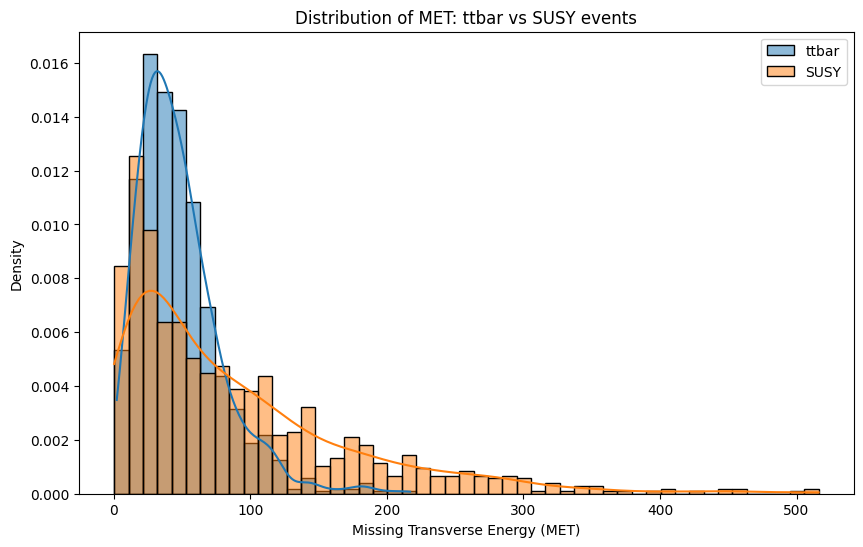


ttbar MET Statistics:
Mean MET: 48.02
Median MET: 41.84
Std MET: 30.97

SUSY MET Statistics:
Mean MET: 88.30
Median MET: 60.81
Std MET: 85.50


In [64]:
# Calculate MET for both ttbar and SUSY events
def calculate_met(group):
    pT = group['pT_truth']
    phi = group['phi_truth']
    
    valid_mask = ~(pT.isna() | phi.isna())
    pT = pT[valid_mask]
    phi = phi[valid_mask]
    
    px = pT * np.cos(phi)
    py = pT * np.sin(phi)
    
    met = np.sqrt(px.sum()**2 + py.sum()**2)
    return met

# Calculate MET for both datasets
ttbar_met = ttbar_all_tracks_df.groupby('event_id').apply(calculate_met)
susy_met = susy_all_tracks_df.groupby('event_id').apply(calculate_met)

# Create overlaid histogram
plt.figure(figsize=(10, 6))
# Use the same bins for both histograms by defining a common range
bins = np.linspace(min(ttbar_met.min(), susy_met.min()), 
                   max(ttbar_met.max(), susy_met.max()), 
                   50)

sns.histplot(data=ttbar_met, label='ttbar', alpha=0.5, stat='density', bins=bins, kde=True)
sns.histplot(data=susy_met, label='SUSY', alpha=0.5, stat='density', bins=bins, kde=True)
plt.xlabel('Missing Transverse Energy (MET)')
plt.ylabel('Density')
plt.title('Distribution of MET: ttbar vs SUSY events')
plt.legend()
plt.show()

# Print statistics for both
print("\nttbar MET Statistics:")
print(f"Mean MET: {ttbar_met.mean():.2f}")
print(f"Median MET: {ttbar_met.median():.2f}")
print(f"Std MET: {ttbar_met.std():.2f}")

print("\nSUSY MET Statistics:")
print(f"Mean MET: {susy_met.mean():.2f}")
print(f"Median MET: {susy_met.median():.2f}")
print(f"Std MET: {susy_met.std():.2f}")

Let's write a classification function by hand: If an event has over 200GeV of missing transverse energy, then we will classify it as SUSY. This is a so-called "cut and count" method, that physicists have been using forever. Let's do this below:

In [65]:
def cut_and_count(met, threshold=200.0):
    """
    Classify an event as signal (SUSY, labeled 1) or background (ttbar, labeled 0) 
    based on the missing transverse energy (MET).

    This "cut and count" function works as follows:
      - If the MET is greater than 200 GeV, the event is classified as SUSY (1).
      - Otherwise, the event is classified as ttbar background (0).

    Parameters:
      event (pd.DataFrame or float): A pre-computed MET value.

    Returns:
      int: 1 if the event is classified as signal (MET > 200 GeV), otherwise 0.
    """

    # Define the MET threshold (in GeV) for a SUSY event
    threshold = 200.0

    # Use a simple threshold cut to classify the event.
    return met > threshold

We apply it as a function to the ttbar and SUSY MET values to see which events passed the cut:

In [66]:
passing_ttbar = cut_and_count(ttbar_met)

Let's just see what this looks like, so it's super clear:

In [67]:
print(passing_ttbar)

event_id
0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool


It's a list of the 1000 events, with a `True` if the event passed the cut, and `False` if it didn't. Now let's count how many events passed the cut:

In [68]:
sum(passing_ttbar)

2

That is 2 out of the 1000 ttbar events passed the cut. Let's see how many SUSY events passed the cut:

In [69]:
passing_susy = cut_and_count(susy_met)

In [70]:
sum(passing_susy)

109

109 of the SUSY events passed the cut, while only 2 of the background events did. That means our cut is very **pure** - it produces almost a "clean" set of signal events. But it's not so **efficient** - we are losing around 90% of the signal events. Let's write these two functions so they are more clear. Efficiency is the the fraction of "true positives" (events that passed the cut that are true) vs. the total number of true events. Purity is the fraction of "true positives" vs. the total number of events that passed the cut.

In [71]:
def efficiency(true_positives, trues):
    return true_positives / trues

def purity(true_positives, positives):
    return true_positives / positives

# Count true positives (SUSY events that passed cut)
true_positives = passing_susy.sum()
# Count total true events (all SUSY events)
trues = len(passing_susy)
# Count total positive predictions (all events that passed cut)
positives = passing_susy.sum() + passing_ttbar.sum()

print(f"Efficiency: {100*efficiency(true_positives, trues):.1f}%")
print(f"Purity: {100*purity(true_positives, positives):.1f}%")

Efficiency: 10.9%
Purity: 98.2%


It might even be useful to see this as a Venn diagram:

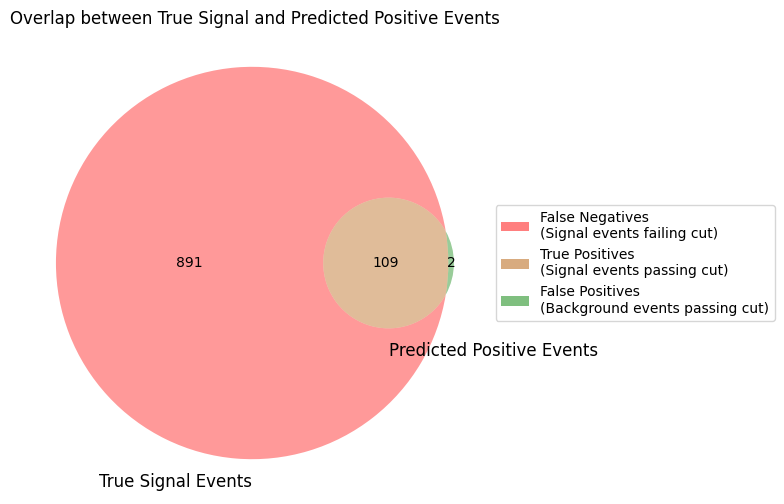


Classification Results:
True Positives (Signal events correctly passing the cut): 109
False Positives (Background events erroneously passing the cut): 2
False Negatives (Signal events failing the cut): 891
True Negatives (Background events correctly failing the cut): 998

Efficiency: 10.9%
Purity: 98.2%


In [73]:
# Add this import at the top with other imports
from matplotlib_venn import venn2

# --- Combine the two datasets into a unified evaluation set ---
# Create an array for the true labels:
# For SUSY events, the true label is True (signal).
# For ttbar events, the true label is False (background).
y_true = np.concatenate([
    np.ones(len(passing_susy), dtype=bool),
    np.zeros(len(passing_ttbar), dtype=bool)
])

# Create a combined predicted results array by concatenating the cut decisions.
predicted = np.concatenate([passing_susy, passing_ttbar])

# --- Create Venn Diagram of True vs Predicted Positives ---

# Get sets of indices for events that are truly signal and for those predicted positive.
true_signal_indices = set(np.where(y_true)[0])
predicted_positive_indices = set(np.where(predicted)[0])

# --- Create Venn Diagram with Legend ---
plt.figure(figsize=(10, 6))
v = venn2([true_signal_indices, predicted_positive_indices],
        set_labels=('True Signal Events', 'Predicted Positive Events'))

# Create legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=v.get_patch_by_id('10').get_facecolor(), alpha=0.5, 
          label='False Negatives\n(Signal events failing cut)'),
    Patch(facecolor=v.get_patch_by_id('11').get_facecolor(), alpha=0.5, 
          label='True Positives\n(Signal events passing cut)'),
    Patch(facecolor=v.get_patch_by_id('01').get_facecolor(), alpha=0.5, 
          label='False Positives\n(Background events passing cut)')
]

plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Overlap between True Signal and Predicted Positive Events')
plt.show()

# --- Calculate and Print Confusion Matrix Components ---

TP = np.sum((y_true == True) & (predicted == True))
FP = np.sum((y_true == False) & (predicted == True))
FN = np.sum((y_true == True) & (predicted == False))
TN = np.sum((y_true == False) & (predicted == False))

print("\nClassification Results:")
print(f"True Positives (Signal events correctly passing the cut): {TP}")
print(f"False Positives (Background events erroneously passing the cut): {FP}")
print(f"False Negatives (Signal events failing the cut): {FN}")
print(f"True Negatives (Background events correctly failing the cut): {TN}")

print(f"\nEfficiency: {100*efficiency(true_positives, trues):.1f}%")
print(f"Purity: {100*purity(true_positives, positives):.1f}%")

Just to nail this home: Efficiency is the fraction of the brown area (true positives) vs. the brown plus red area (all true events). Purity is the fraction of the brown area (true positives) vs. the brown plus green area (all events that passed the cut).

Because ML engineers like to target a SINGLE number when building models, they introduced a number called the "ROC AUC" (Receiver Operating Characteristic Area Under the Curve). This is the area under the ROC curve, which is a plot of the true positive rate vs the false positive rate at different threshold cuts. That might sound confusing and arbitrary, but it's actually a really good way to summarize the performance of a binary classifier. What it's saying is:
- For some choice (e.g. a threshold of 200GeV cut), how many "true positives" (signal events) did we get?
- For some choice (e.g. a threshold of 200GeV cut), how many "false positives" (background events) did we get?
- The ROC curve is a plot of the false positive rate vs the true positive rate, as we change the threshold cut.
- The ROC AUC is the area under this curve.
- A perfect classifier would have an ROC AUC of 1.0.
- A random classifier (e.g. flipping a coin) would have an ROC AUC of 0.5.

Let's calculate the ROC AUC for our classifier:

ROC AUC: 0.609


Text(0.5, 1.0, 'Receiver Operating Characteristic (ROC) Curve')

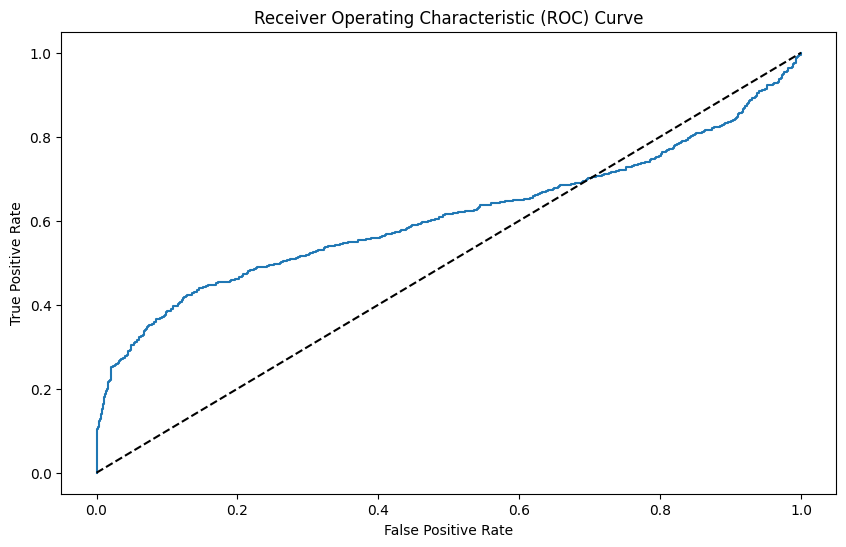

In [74]:
import numpy as np
from sklearn.metrics import roc_curve, auc

# Combine the MET scores of the signal (SUSY) and background (ttbar) events
# Here, susy_met and ttbar_met are assumed to be pandas Series or numpy arrays.
y_true = np.concatenate([np.ones(len(susy_met)), np.zeros(len(ttbar_met))])
met_scores = np.concatenate([susy_met.values, ttbar_met.values])  # or simply susy_met and ttbar_met if they are numpy arrays

# Compute the ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_true, met_scores)

# Compute the AUC from the FPR and TPR values
roc_auc = auc(fpr, tpr)

print(f"ROC AUC: {roc_auc:.3f}")

# Let's plot the ROC curve:
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')

Okay! We got a ROC of 0.609. That's actually not bad for a simple cut... but we can do better! And in fact the first couple of weeks of the project should be spent getting this AUC value as high as possible. Just to remind how it works:
- We calculate a ROC curve function, from:
    - The true information (y_true, which is either 0 or 1 for each event)
    - The predicted information (met_scores, which is the MET value for each event). This is normally a score between 0 and 1, but here we are using the MET as a "score". The ROC curve function will normalize this between 0 and 1 for us.
- This function gives us the plot above
- Then we use the auc function, which calculates the area under that curve. If the curve goes straight up and stays at one, then the AUC is 1.0, and the classifier is perfect. That is, for a 0 false positive rate, it has a 100% true positive rate.

## Building a simple classifier with ML

Now, let's try to build a simple classifier using ML. We will use a simple "least squares" linear regression classifier, which is a type of "linear" classifier. The way it works is by trying to draw a straight line that separates the signal (SUSY) from the background (ttbar), in some space of features.





There is one slightly tricky thing to think about: a linear regression classifier takes in a fixed number of features for each event. That means that we need to convert our events (a list of tracks, *each* with a set of features) into a single set of features for each event. That means we need to do something like this:
1. Take the top N tracks in each event, sorted by pT
2. Calculate the features for each of those tracks
3. Concatenate (stack) those features together
4. Use those features to classify the event

If an event has less than N tracks, we will just pad (fill it) with zeros. It might be useful to know how many tracks are in each event...

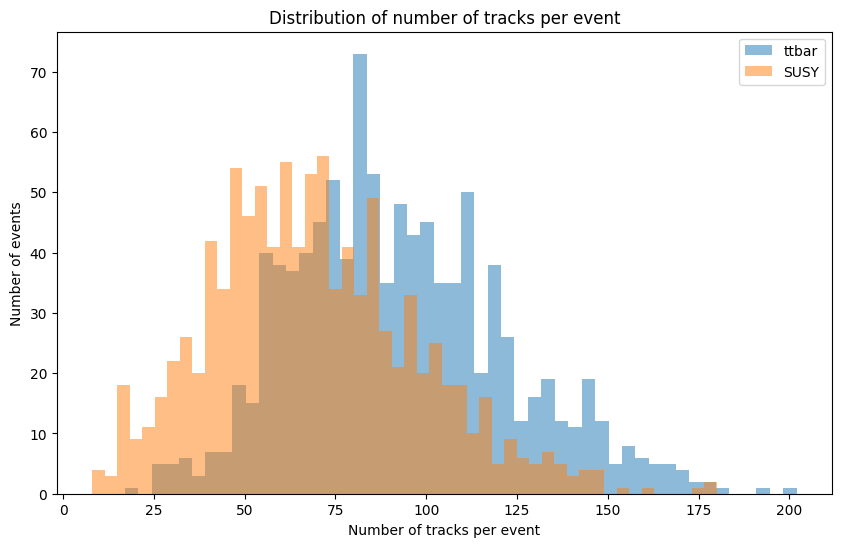

In [75]:
# Plot histogram of number of tracks per event
plt.figure(figsize=(10, 6))
plt.hist(ttbar_all_tracks_df.groupby("event_id").size(), bins=50, alpha=0.5, label='ttbar')
plt.hist(susy_all_tracks_df.groupby("event_id").size(), bins=50, alpha=0.5, label='SUSY')
plt.xlabel('Number of tracks per event')
plt.ylabel('Number of events')
plt.title('Distribution of number of tracks per event')
plt.legend()
plt.show()

Okay, so both datasets have around 100 tracks per event, but some events have 10, and some have 200. It's a big spread! But since we sort the tracks by pT, we know that the first few tracks are the most "important". So let's just take the top 10 tracks for each event for now.

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

def prepare_event_features(df_group, n_tracks=10, features=['d0_truth', 'z0_truth', 'phi_truth', 
                                                          'theta_truth', 'charge_truth', 'p_truth', 'pT_truth']):
    """
    Prepare fixed-length feature vector for an event by taking top N tracks sorted by pT
    
    Args:
        df_group: DataFrame group containing all tracks for one event
        n_tracks: Number of top tracks to keep
        features: List of track features to use
    
    Returns:
        Numpy array of concatenated features with shape (n_tracks * len(features),)
    """
    # Sort tracks by pT
    sorted_tracks = df_group.sort_values('pT_truth', ascending=False)
    
    # Initialize array for fixed number of tracks
    track_features = np.zeros((n_tracks, len(features)))
    
    # Fill available tracks
    n_available = min(len(sorted_tracks), n_tracks)
    track_features[:n_available] = sorted_tracks[features].iloc[:n_available].values
    
    # Flatten array to 1D
    return track_features.flatten()

# Prepare features for all events
def prepare_dataset(df, n_tracks=10):
    """
    Prepare features for all events in the dataset
    
    Args:
        df: DataFrame containing all tracks from all events
        n_tracks: Number of top tracks to keep per event
    
    Returns:
        X: Array of shape (n_events, n_tracks * n_features)
    """
    features = ['d0_truth', 'z0_truth', 'phi_truth', 'theta_truth',
               'charge_truth', 'p_truth', 'pT_truth']
    
    # Group by event_id and prepare features for each event
    X = np.array([
        prepare_event_features(group, n_tracks, features) 
        for _, group in df.groupby('event_id')
    ])
    
    return X

# Prepare features for both datasets
number_of_tracks = 10
X_ttbar = prepare_dataset(ttbar_all_tracks_df, n_tracks=number_of_tracks)
X_susy = prepare_dataset(susy_all_tracks_df, n_tracks=number_of_tracks)


Now let's use the scikit-learn library to build a simple linear regression classifier. We will use the ROC AUC score to evaluate the performance of the classifier. One thing to note: Since we are **training** this model, we need to split the data into training and test sets. We will evaluate the performance of the model on the test set, which is only 20% of the data (400 events).

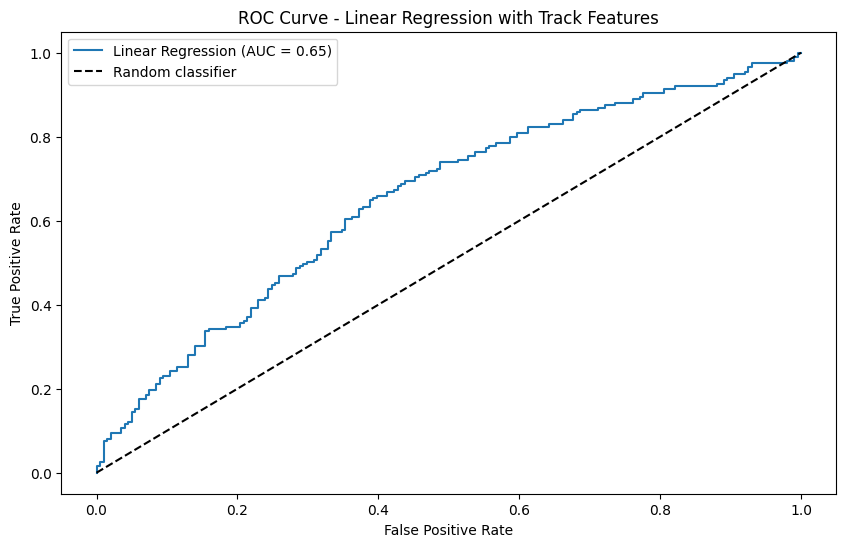

In [77]:
# Let's try an ordinary least squares linear regression classifier:
from sklearn.linear_model import LinearRegression

# Combine datasets and create labels
X = np.vstack([X_susy, X_ttbar])
y = np.concatenate([np.ones(len(X_susy)), np.zeros(len(X_ttbar))])

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train linear regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Evaluate
y_pred = lin_reg.predict(X_test)
roc_auc = roc_auc_score(y_test, y_pred)

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'Linear Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Linear Regression with Track Features')
plt.legend()
plt.show()




Okay! We got a ROC AUC of 0.65 - that's better than our cut! Next, you should check out the VERY long list of classification algorithms that scikit-learn supports, and try out a few others! Also try to change the number of tracks we use to make the features, and see how that affects the performance of the classifier. See how good the AUC can get!

FYI, we will use this pattern a lot, so let's make a function so we don't have to keep re-writing it:

In [78]:
def train_and_evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Train a model and evaluate its performance with ROC curve
    
    Args:
        model: sklearn model object
        X_train: Training features
        X_test: Test features  
        y_train: Training labels
        y_test: Test labels
        model_name: Name of model for plot title
        
    Returns:
        roc_auc: ROC AUC score
        y_pred: Model predictions on test set
    """
    # Train model
    model.fit(X_train, y_train)
    
    # Get predictions
    y_pred = model.predict(X_test)
    
    # Calculate ROC AUC
    roc_auc = roc_auc_score(y_test, y_pred)
    
    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name} with Track Features')
    plt.legend()
    plt.show()
    
    return roc_auc, y_pred

Let's test it out with a decision tree classifier:

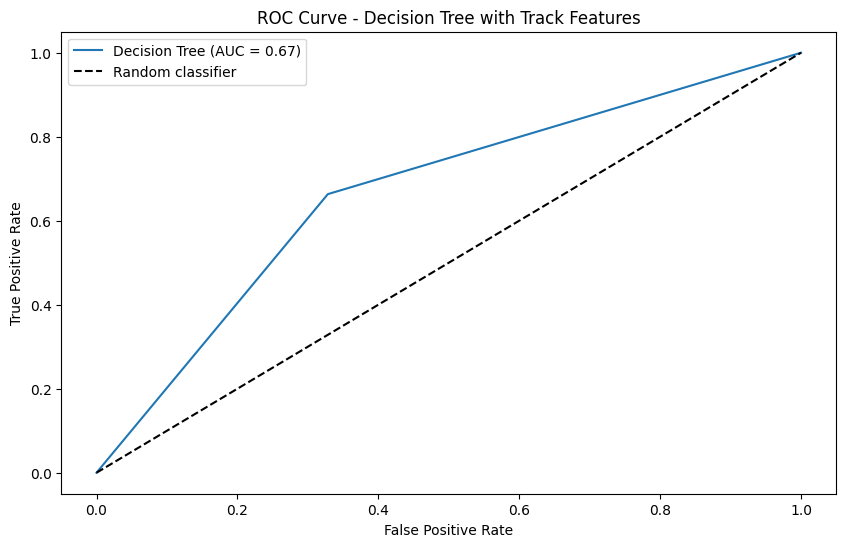

In [79]:
# Try a decision tree classifier:
from sklearn.tree import DecisionTreeClassifier

# Train decision tree
clf = DecisionTreeClassifier()

roc_auc, y_pred = train_and_evaluate_model(clf, X_train, X_test, y_train, y_test, "Decision Tree")

Nice! Even better AUC. Check out the scikit-learn documentation (https://scikit-learn.org/stable/supervised_learning.html) for more information on the different types of linear regression classifiers. Almost all of the can be dropped into the train_and_evaluate_model function! E.g. let's try a random forest classifier:

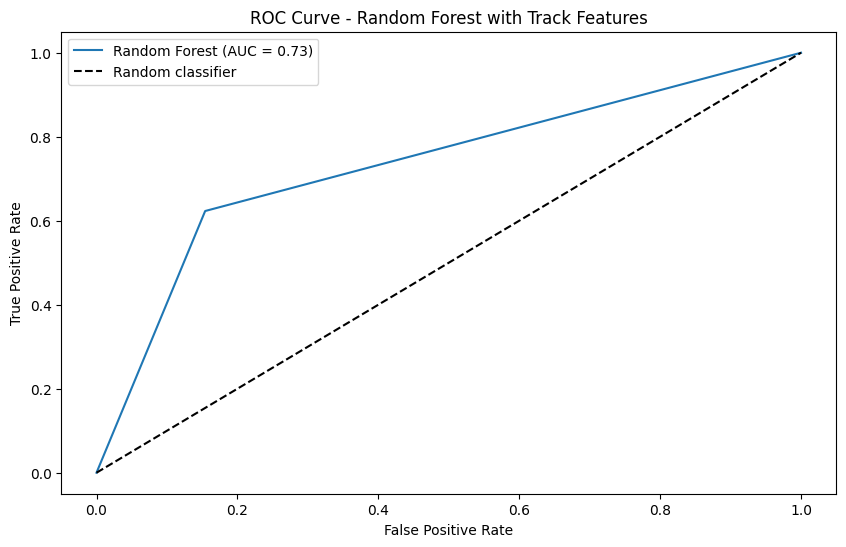

In [80]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()

roc_auc, y_pred = train_and_evaluate_model(clf, X_train, X_test, y_train, y_test, "Random Forest")


Getting better... Just to call back to the Venn diagram, let's see how this Random Forest classifier performs:

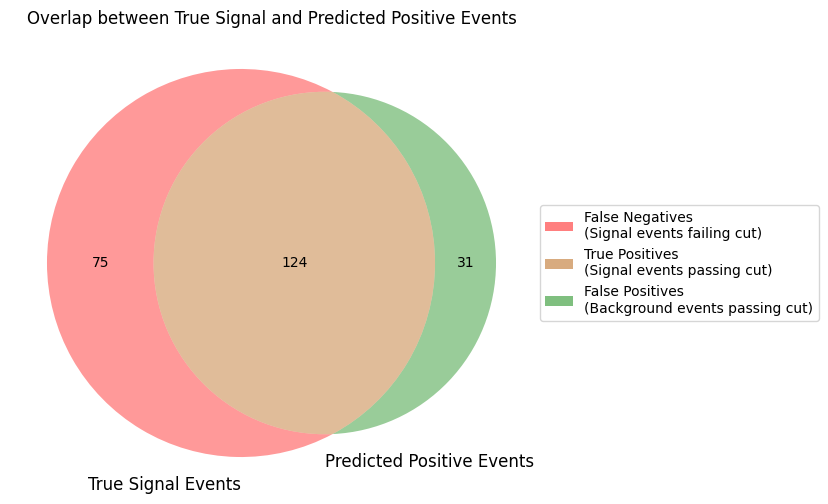

Efficiency: 62.3%
Purity: 80.0%


In [81]:
# --- Create Venn Diagram of True vs Predicted Positives ---

# Get sets of indices for events that are truly signal and for those predicted positive.
true_signal_indices = set(np.where(y_test)[0])
predicted_positive_indices = set(np.where(y_pred)[0])

# --- Create Venn Diagram with Legend ---
plt.figure(figsize=(10, 6))
v = venn2([true_signal_indices, predicted_positive_indices],
        set_labels=('True Signal Events', 'Predicted Positive Events'))

# Create legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=v.get_patch_by_id('10').get_facecolor(), alpha=0.5, 
          label='False Negatives\n(Signal events failing cut)'),
    Patch(facecolor=v.get_patch_by_id('11').get_facecolor(), alpha=0.5, 
          label='True Positives\n(Signal events passing cut)'),
    Patch(facecolor=v.get_patch_by_id('01').get_facecolor(), alpha=0.5, 
          label='False Positives\n(Background events passing cut)')
]

plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Overlap between True Signal and Predicted Positive Events')
plt.show()

# Convert predictions to boolean arrays for bitwise operations
y_pred_bool = y_pred.astype(bool)
y_test_bool = y_test.astype(bool)

trues = y_test.sum()
positives = y_pred.sum()
true_positives = (y_pred_bool & y_test_bool).sum()

# Print efficiency and purity
print(f"Efficiency: {100*efficiency(true_positives, trues):.1f}%")
print(f"Purity: {100*purity(true_positives, positives):.1f}%")


You can see our purity has dropped from ~90% to ~80%, so we're picking up some extra background. But we're finding 6x as many signal events than our simple cut!

Go ahead and try out a few more classifiers! See how high you can get the AUC, the efficiency and the purity!